In [48]:
import os

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[4]")
    .appName("AmazonSportsNLP")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

print("Spark Version:", spark.version)
print("Driver Memory:", spark.conf.get("spark.driver.memory"))

Spark Version: 4.1.2
Driver Memory: 8g


In [49]:
# PySpark Functions

from pyspark.sql.functions import (
    col,
    count,
    countDistinct,
    avg,
    sum,
    min,
    max,
    desc,
    asc,
    year,
    month,
    when
)

# Pandas

import pandas as pd

# Visualization

import matplotlib.pyplot as plt

# Optional Better Styling

plt.style.use("ggplot")

# Display All Columns

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)

pd.set_option(
    "display.width",
    200
)

In [3]:
final_v5 = spark.read.parquet(
    r"C:\Users\affaa\OneDrive\Desktop\CDAC_PROJECT\raw_data\final_joined_dataset_v5.parquet"
)

print(
    "Total Records:",
    final_v5.count()
)

Total Records: 19595170


# Dataset Overview

This section provides a high-level summary of the dataset including review volume, product diversity and customer activity.

In [4]:
print(
    "Total Reviews:",
    final_v5.count()
)

print(
    "Unique Products:",
    final_v5.select(
        countDistinct("parent_asin")
    ).first()[0]
)

print(
    "Categories:",
    final_v5.select(
        countDistinct("final_category")
    ).first()[0]
)

print(
    "Average Rating:",
    round(
        final_v5.select(
            avg("rating")
        ).first()[0],
        2
    )
)

Total Reviews: 19595170
Unique Products: 1587219
Categories: 16
Average Rating: 4.22


# Executive Overview & Marketplace Performance Dashboard

This dashboard provides a high-level overview of customer engagement, product popularity and overall marketplace performance.

The visualizations help identify dominant product categories, customer satisfaction levels and highly reviewed products.

In [7]:
from pyspark.sql.functions import count, desc

category_reviews = (
    final_v5
    .groupBy("final_category")
    .agg(
        count("*").alias("review_count")
    )
    .orderBy(
        desc("review_count")
    )
)

category_reviews_pd = category_reviews.toPandas()

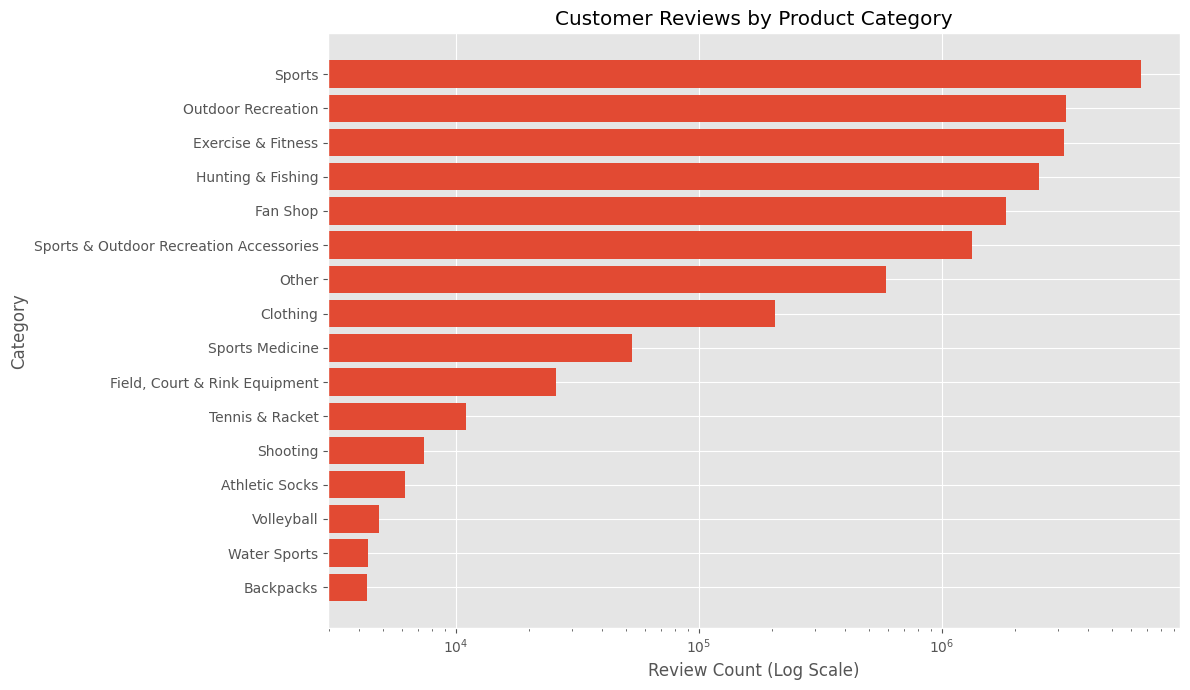

In [9]:
plt.figure(figsize=(12,7))

plt.barh(
    category_reviews_pd["final_category"],
    category_reviews_pd["review_count"]
)

plt.xscale("log")

plt.xlabel("Review Count (Log Scale)")
plt.ylabel("Category")

plt.title(
    "Customer Reviews by Product Category"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [10]:
from pyspark.sql.functions import avg

category_rating = (
    final_v5
    .groupBy("final_category")
    .agg(
        avg("rating").alias("avg_rating")
    )
    .orderBy(
        desc("avg_rating")
    )
)

category_rating_pd = category_rating.toPandas()

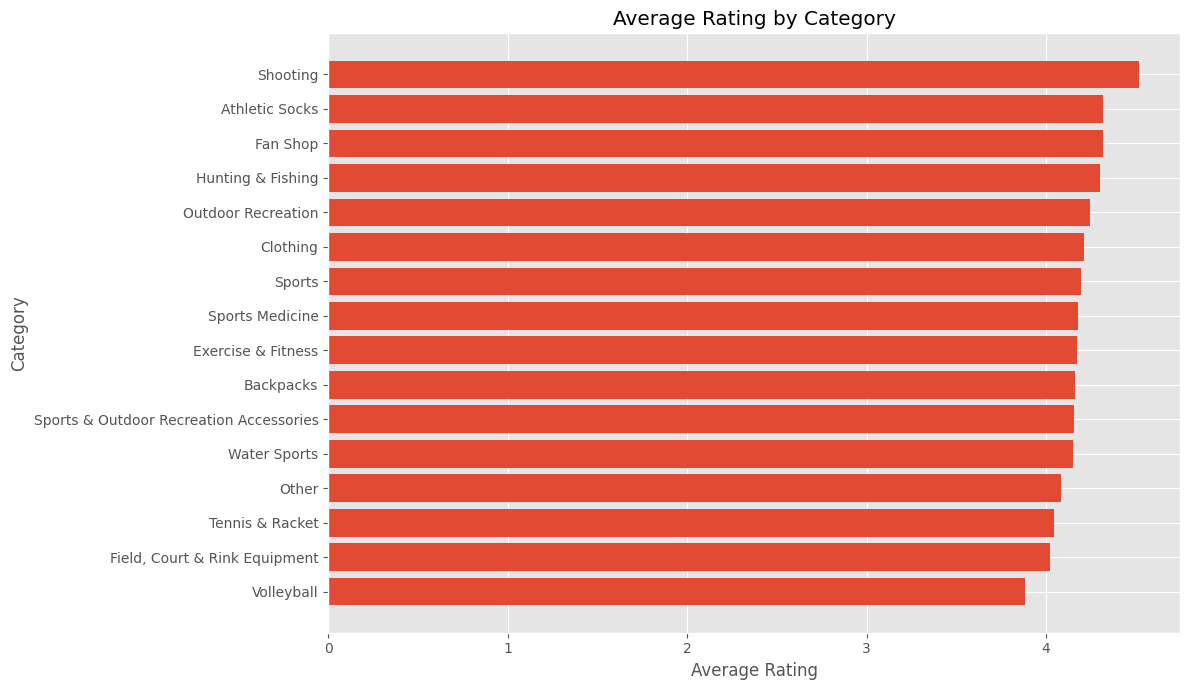

In [11]:
plt.figure(figsize=(12,7))

plt.barh(
    category_rating_pd["final_category"],
    category_rating_pd["avg_rating"]
)

plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.title("Average Rating by Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [12]:
market_share = (
    final_v5
    .groupBy("final_category")
    .agg(
        count("*").alias("reviews")
    )
)

market_share_pd = market_share.toPandas()

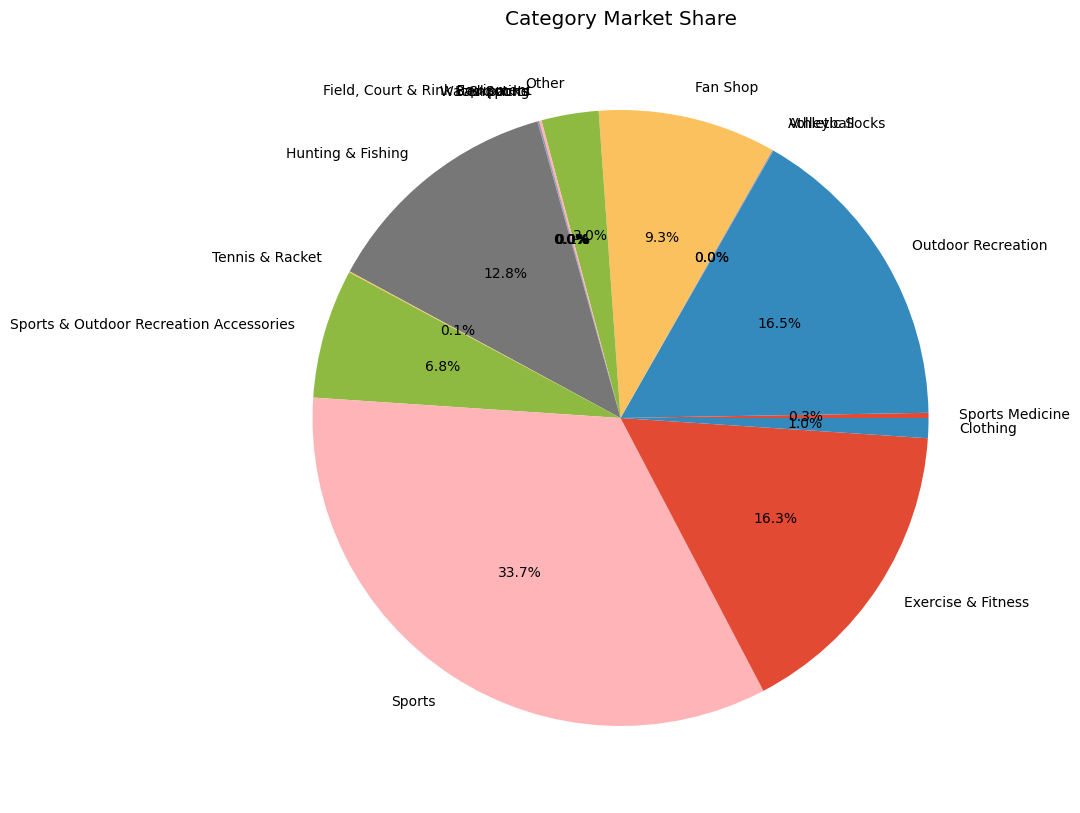

In [13]:
plt.figure(figsize=(10,10))

plt.pie(
    market_share_pd["reviews"],
    labels=market_share_pd["final_category"],
    autopct="%1.1f%%"
)

plt.title("Category Market Share")

plt.show()

In [14]:
top_products = (
    final_v5
    .groupBy(
        "product_name"
    )
    .agg(
        count("*").alias("reviews")
    )
    .orderBy(
        desc("reviews")
    )
    .limit(10)
)

top_products_pd = top_products.toPandas()

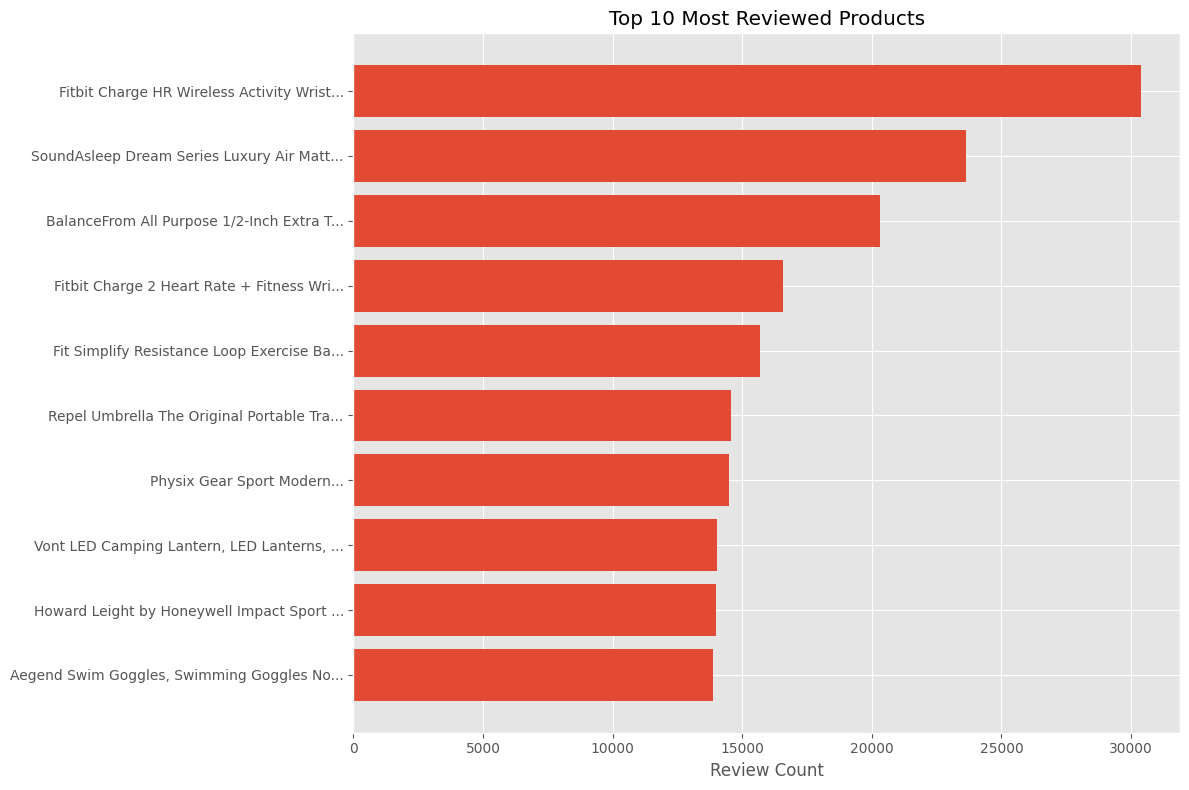

In [18]:
top_products_pd["short_name"] = (
    top_products_pd["product_name"]
    .str[:40] + "..."
)

plt.figure(figsize=(12,8))

plt.barh(
    top_products_pd["short_name"],
    top_products_pd["reviews"]
)

plt.xlabel("Review Count")
plt.title("Top 10 Most Reviewed Products")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [16]:
rating_dist = (
    final_v5
    .groupBy("rating")
    .count()
    .orderBy("rating")
)

rating_dist_pd = rating_dist.toPandas()

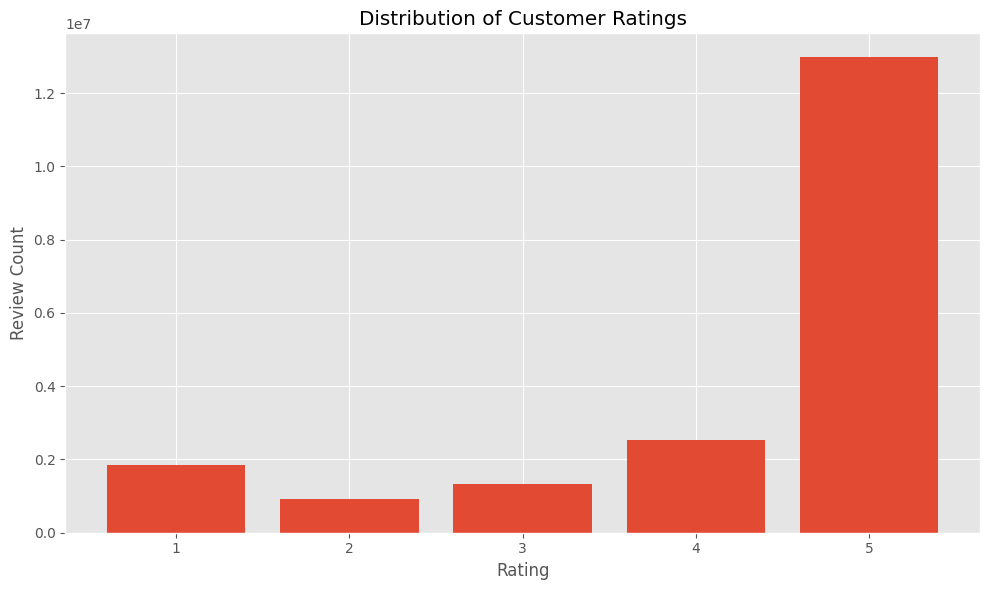

In [17]:
plt.figure(figsize=(10,6))

plt.bar(
    rating_dist_pd["rating"],
    rating_dist_pd["count"]
)

plt.xlabel("Rating")
plt.ylabel("Review Count")

plt.title("Distribution of Customer Ratings")

plt.tight_layout()

plt.show()

# Customer Sentiment Analytics Dashboard

This dashboard analyzes customer opinions and sentiment patterns extracted from review data.

The visualizations help identify overall customer satisfaction, category-level sentiment trends and the relationship between sentiment and ratings.

In [20]:
sentiment_dist = (
    final_v5
    .groupBy("sentiment")
    .count()
    .orderBy(desc("count"))
)

sentiment_pd = sentiment_dist.toPandas()

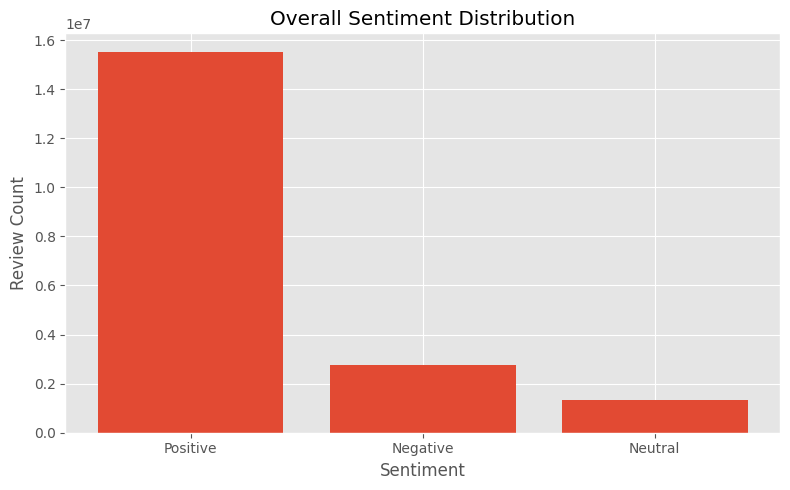

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    sentiment_pd["sentiment"],
    sentiment_pd["count"]
)

plt.xlabel("Sentiment")
plt.ylabel("Review Count")

plt.title(
    "Overall Sentiment Distribution"
)

plt.tight_layout()

plt.show()

In [22]:
sentiment_category = (
    final_v5
    .groupBy(
        "final_category",
        "sentiment"
    )
    .count()
)

sentiment_category_pd = (
    sentiment_category
    .toPandas()
)

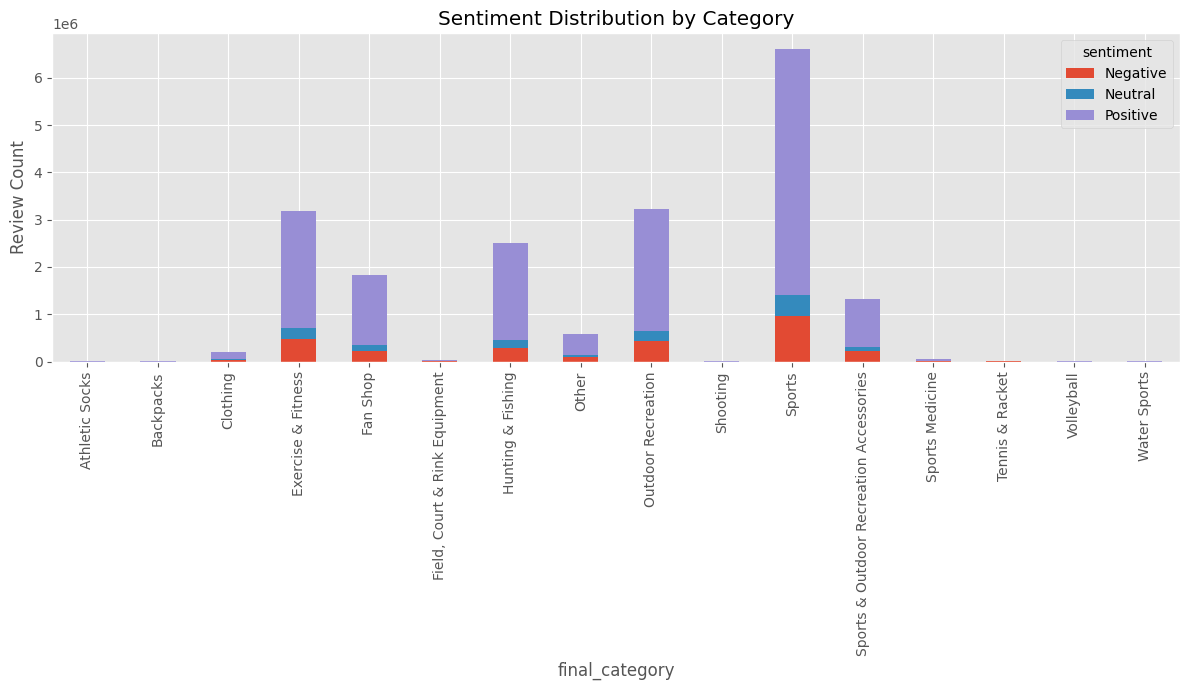

In [23]:
pivot_df = sentiment_category_pd.pivot(
    index="final_category",
    columns="sentiment",
    values="count"
).fillna(0)

pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.title(
    "Sentiment Distribution by Category"
)

plt.ylabel(
    "Review Count"
)

plt.tight_layout()

plt.show()

In [24]:
rating_sentiment = (
    final_v5
    .groupBy("sentiment")
    .agg(
        avg("rating").alias(
            "avg_rating"
        )
    )
)

rating_sentiment_pd = (
    rating_sentiment
    .toPandas()
)

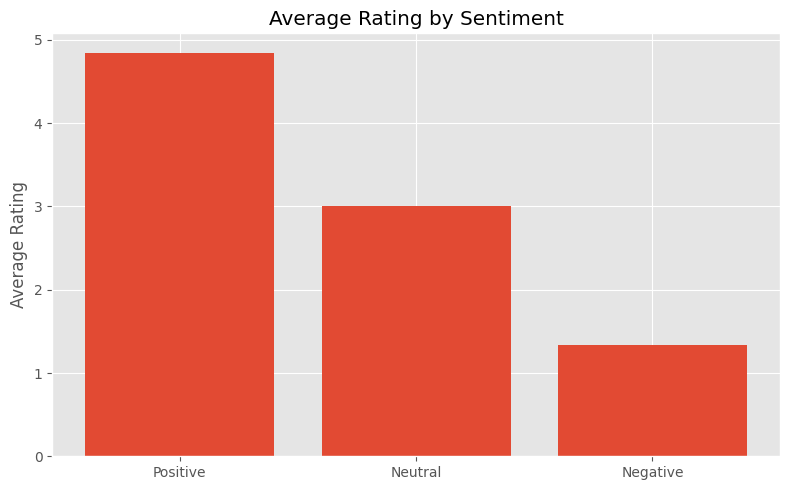

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    rating_sentiment_pd["sentiment"],
    rating_sentiment_pd["avg_rating"]
)

plt.ylabel(
    "Average Rating"
)

plt.title(
    "Average Rating by Sentiment"
)

plt.tight_layout()

plt.show()

In [26]:
review_length_sentiment = (
    final_v5
    .groupBy("sentiment")
    .agg(
        avg(
            "review_length"
        ).alias(
            "avg_review_length"
        )
    )
)

review_length_pd = (
    review_length_sentiment
    .toPandas()
)

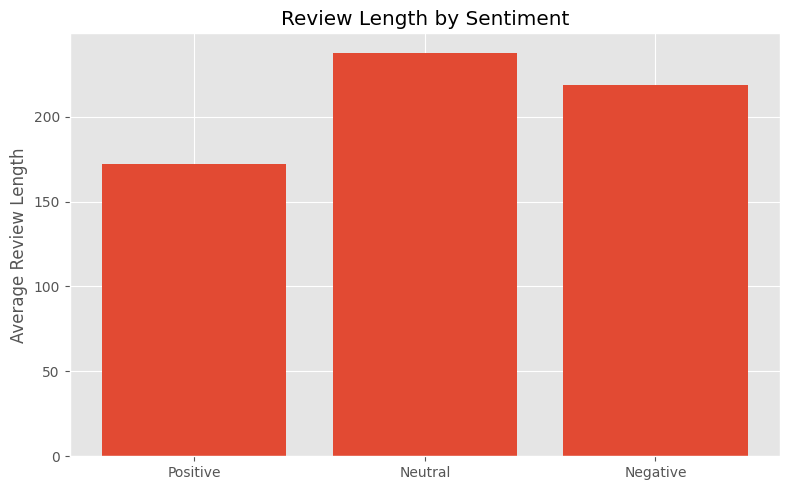

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    review_length_pd["sentiment"],
    review_length_pd["avg_review_length"]
)

plt.ylabel(
    "Average Review Length"
)

plt.title(
    "Review Length by Sentiment"
)

plt.tight_layout()

plt.show()

In [28]:
helpful_sentiment = (
    final_v5
    .groupBy("sentiment")
    .agg(
        avg(
            "helpful_vote"
        ).alias(
            "avg_helpful_votes"
        )
    )
)

helpful_pd = (
    helpful_sentiment
    .toPandas()
)

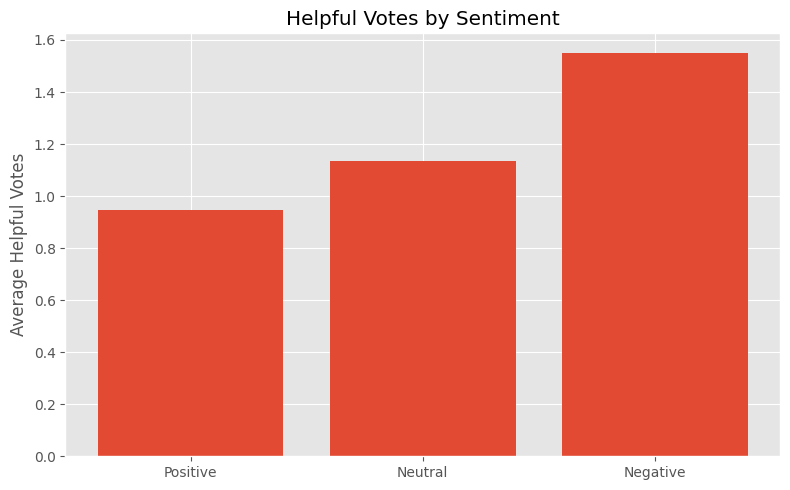

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    helpful_pd["sentiment"],
    helpful_pd["avg_helpful_votes"]
)

plt.ylabel(
    "Average Helpful Votes"
)

plt.title(
    "Helpful Votes by Sentiment"
)

plt.tight_layout()

plt.show()

In [30]:
heatmap_df = (
    final_v5
    .groupBy(
        "sentiment",
        "rating"
    )
    .count()
    .toPandas()
)

In [31]:
heatmap_table = (
    heatmap_df
    .pivot(
        index="sentiment",
        columns="rating",
        values="count"
    )
    .fillna(0)
)

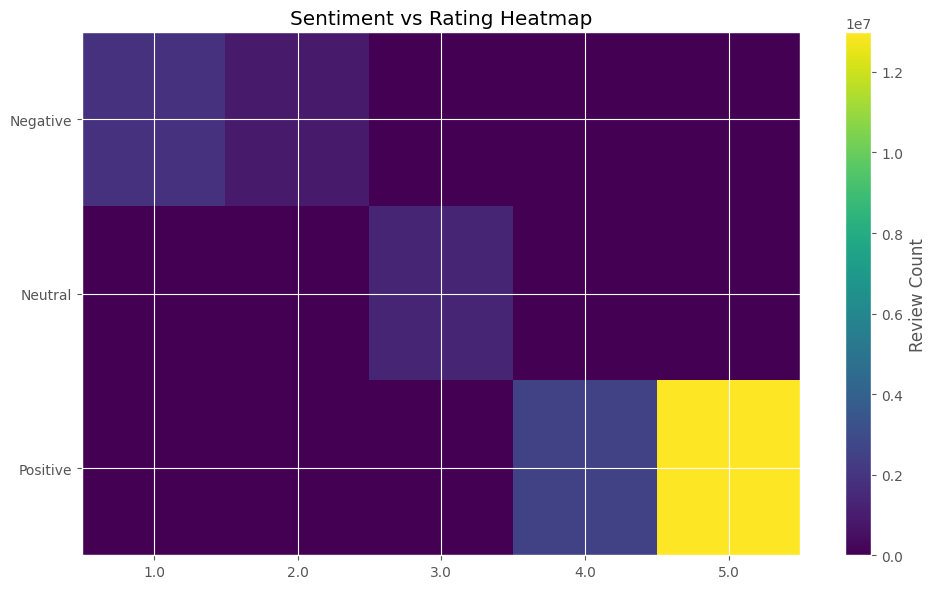

In [32]:
plt.figure(figsize=(10,6))

plt.imshow(
    heatmap_table,
    aspect="auto"
)

plt.colorbar(
    label="Review Count"
)

plt.xticks(
    range(
        len(
            heatmap_table.columns
        )
    ),
    heatmap_table.columns
)

plt.yticks(
    range(
        len(
            heatmap_table.index
        )
    ),
    heatmap_table.index
)

plt.title(
    "Sentiment vs Rating Heatmap"
)

plt.tight_layout()

plt.show()

# Review Trends & Time Series Analytics

This dashboard analyzes review activity over time to understand customer engagement trends, marketplace growth and sentiment evolution.

The visualizations provide insights into how customer participation and satisfaction have changed across years.

In [33]:
from pyspark.sql.functions import count

yearly_reviews = (
    final_v5
    .groupBy("review_year")
    .agg(
        count("*").alias("reviews")
    )
    .orderBy("review_year")
)

yearly_reviews_pd = yearly_reviews.toPandas()

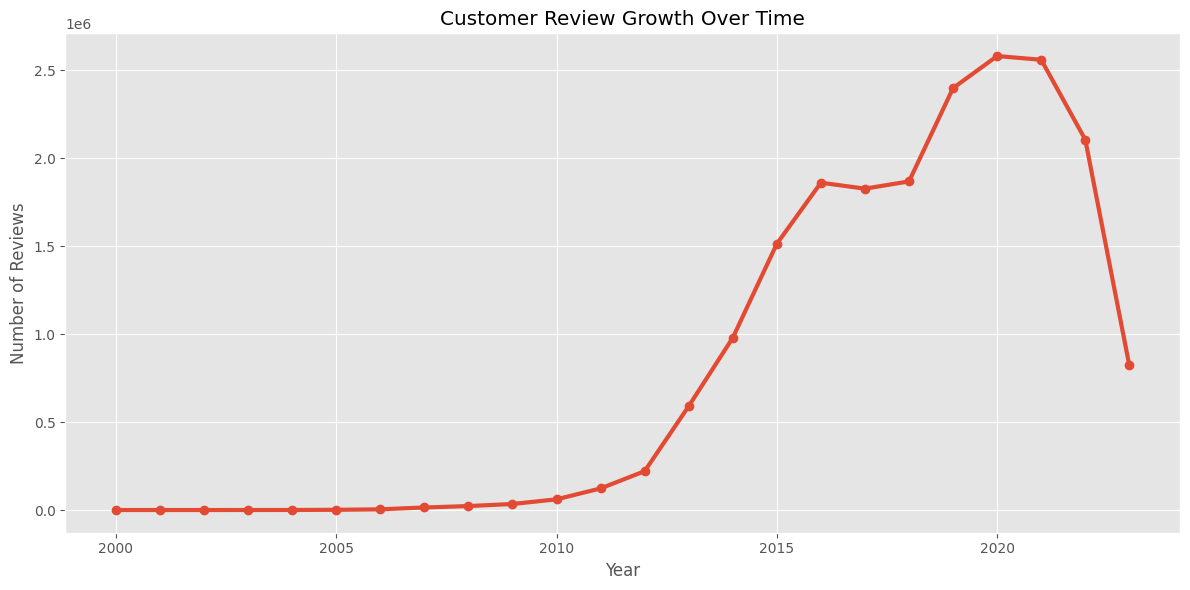

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_reviews_pd["review_year"],
    yearly_reviews_pd["reviews"],
    marker="o",
    linewidth=3
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.title(
    "Customer Review Growth Over Time"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [35]:
from pyspark.sql.functions import avg

yearly_rating = (
    final_v5
    .groupBy("review_year")
    .agg(
        avg("rating").alias("avg_rating")
    )
    .orderBy("review_year")
)

yearly_rating_pd = yearly_rating.toPandas()

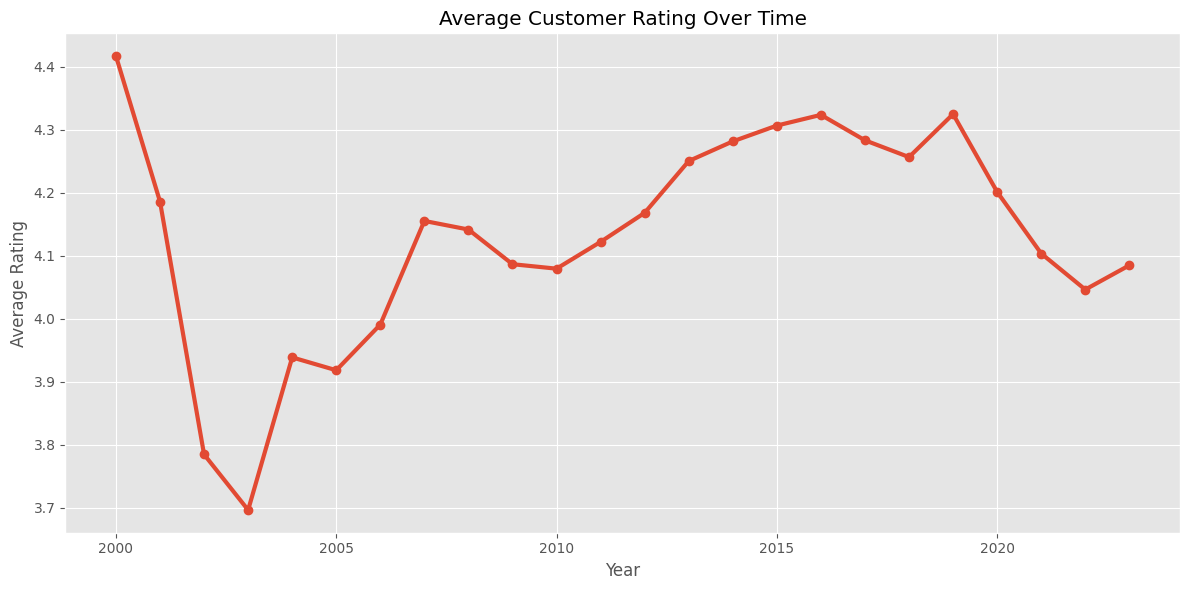

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_rating_pd["review_year"],
    yearly_rating_pd["avg_rating"],
    marker="o",
    linewidth=3
)

plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.title(
    "Average Customer Rating Over Time"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [37]:
sentiment_year = (
    final_v5
    .groupBy(
        "review_year",
        "sentiment"
    )
    .count()
)

sentiment_year_pd = (
    sentiment_year
    .toPandas()
)

In [38]:
pivot_sentiment = (
    sentiment_year_pd
    .pivot(
        index="review_year",
        columns="sentiment",
        values="count"
    )
    .fillna(0)
)

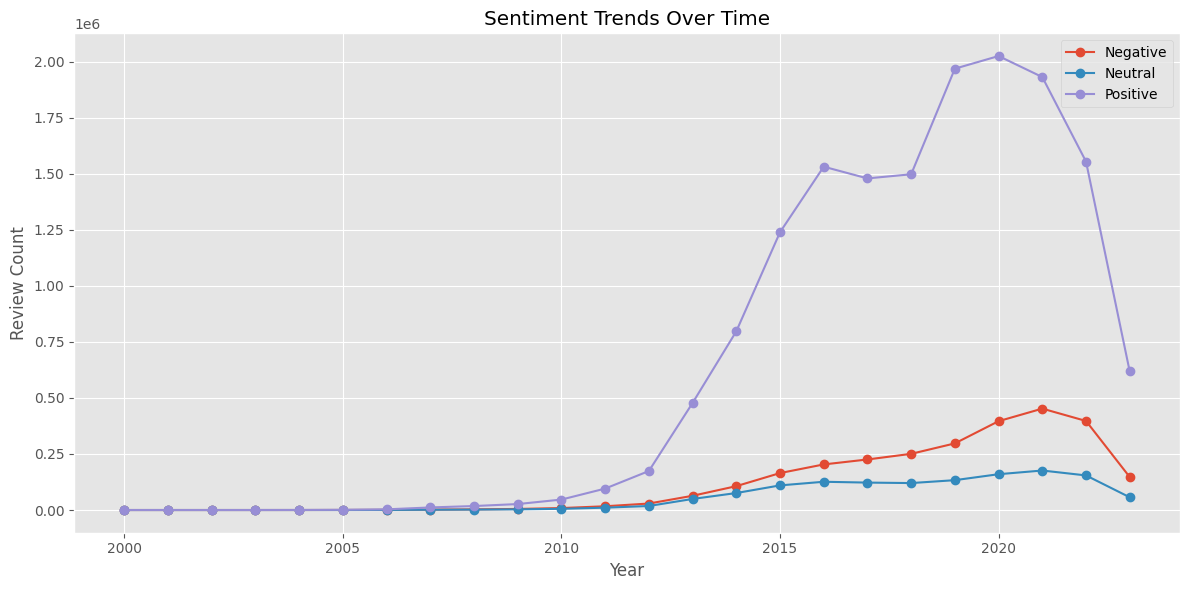

In [39]:
plt.figure(figsize=(12,6))

for sentiment in pivot_sentiment.columns:
    
    plt.plot(
        pivot_sentiment.index,
        pivot_sentiment[sentiment],
        marker="o",
        label=sentiment
    )

plt.title(
    "Sentiment Trends Over Time"
)

plt.xlabel("Year")
plt.ylabel("Review Count")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [40]:
verified_year = (
    final_v5
    .groupBy(
        "review_year",
        "verified_purchase"
    )
    .count()
)

verified_pd = (
    verified_year
    .toPandas()
)

In [41]:
verified_pivot = (
    verified_pd
    .pivot(
        index="review_year",
        columns="verified_purchase",
        values="count"
    )
    .fillna(0)
)

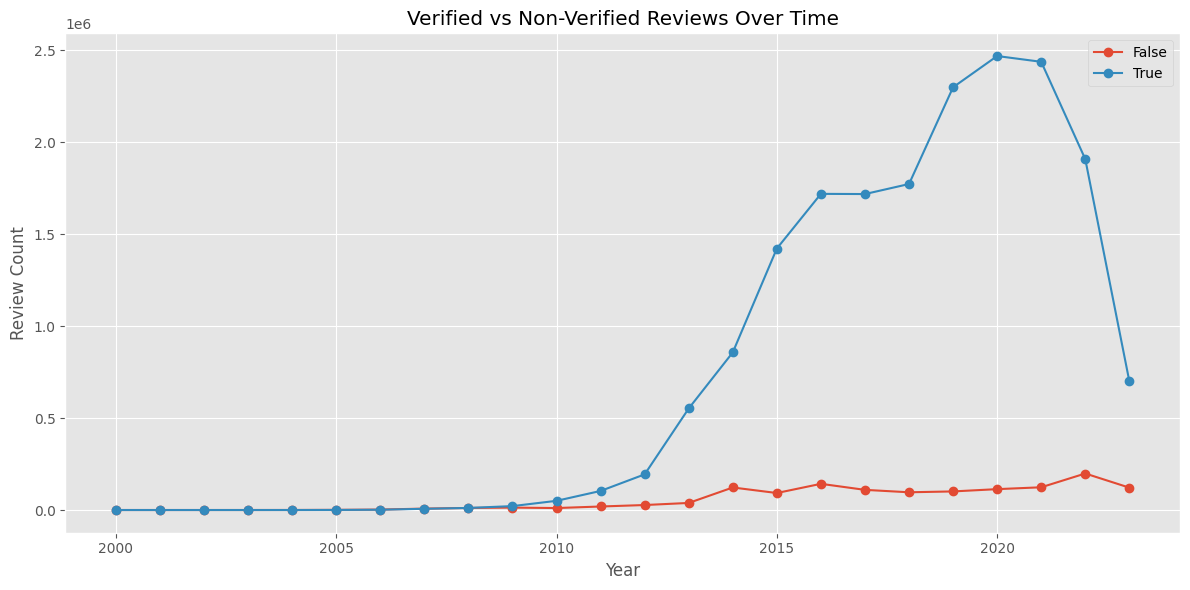

In [42]:
plt.figure(figsize=(12,6))

for col_name in verified_pivot.columns:

    plt.plot(
        verified_pivot.index,
        verified_pivot[col_name],
        marker="o",
        label=str(col_name)
    )

plt.title(
    "Verified vs Non-Verified Reviews Over Time"
)

plt.xlabel("Year")
plt.ylabel("Review Count")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [43]:
top_categories = [
    "Sports",
    "Outdoor Recreation",
    "Exercise & Fitness",
    "Hunting & Fishing"
]

category_year = (
    final_v5
    .filter(
        col("final_category").isin(
            top_categories
        )
    )
    .groupBy(
        "review_year",
        "final_category"
    )
    .count()
)

category_year_pd = (
    category_year
    .toPandas()
)

In [44]:
pivot_category = (
    category_year_pd
    .pivot(
        index="review_year",
        columns="final_category",
        values="count"
    )
    .fillna(0)
)

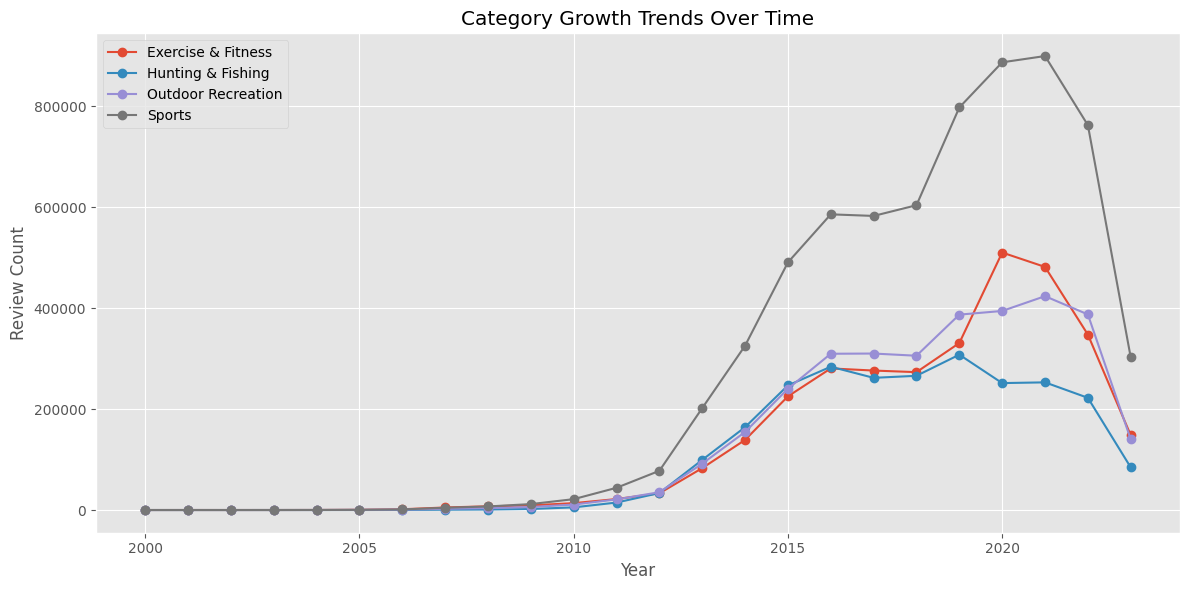

In [45]:
plt.figure(figsize=(12,6))

for category in pivot_category.columns:

    plt.plot(
        pivot_category.index,
        pivot_category[category],
        marker="o",
        label=category
    )

plt.title(
    "Category Growth Trends Over Time"
)

plt.xlabel("Year")
plt.ylabel("Review Count")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [46]:
yearly_stats = (
    final_v5
    .groupBy("review_year")
    .agg(
        count("*").alias("reviews"),
        avg("rating").alias("avg_rating")
    )
    .orderBy("review_year")
)

yearly_stats_pd = (
    yearly_stats
    .toPandas()
)

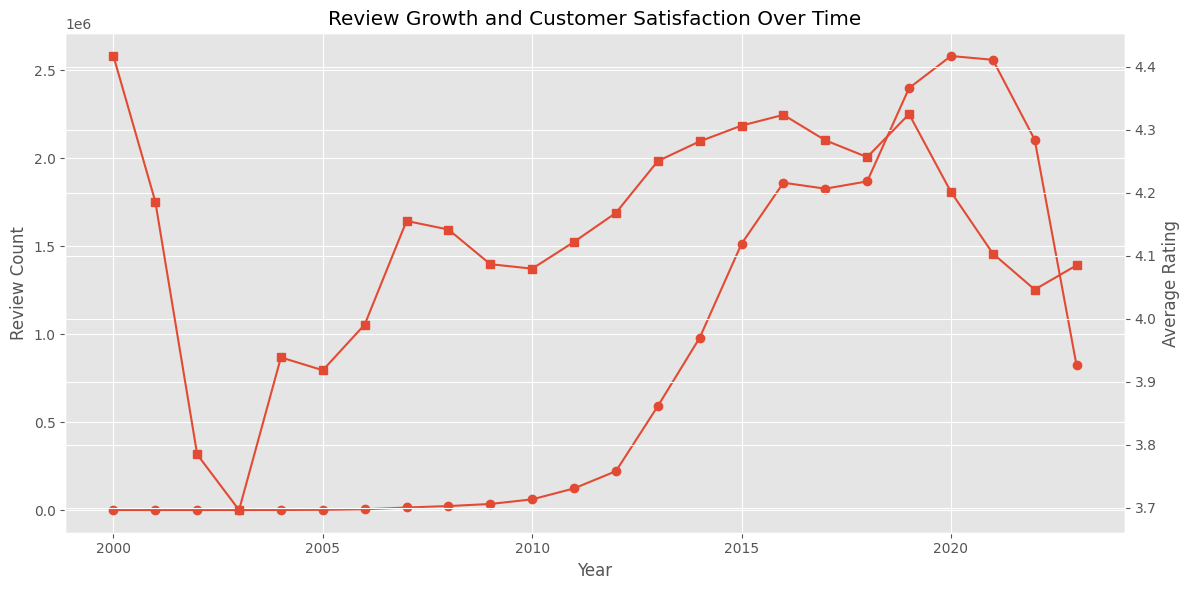

In [47]:
fig, ax1 = plt.subplots(
    figsize=(12,6)
)

ax1.plot(
    yearly_stats_pd["review_year"],
    yearly_stats_pd["reviews"],
    marker="o"
)

ax1.set_ylabel(
    "Review Count"
)

ax1.set_xlabel(
    "Year"
)

ax2 = ax1.twinx()

ax2.plot(
    yearly_stats_pd["review_year"],
    yearly_stats_pd["avg_rating"],
    marker="s"
)

ax2.set_ylabel(
    "Average Rating"
)

plt.title(
    "Review Growth and Customer Satisfaction Over Time"
)

plt.tight_layout()

plt.show()

In [50]:
brand_reviews = (
    final_v5
    .filter(col("store").isNotNull())
    .groupBy("store")
    .agg(
        count("*").alias("reviews")
    )
    .orderBy(desc("reviews"))
    .limit(15)
)

brand_reviews_pd = brand_reviews.toPandas()

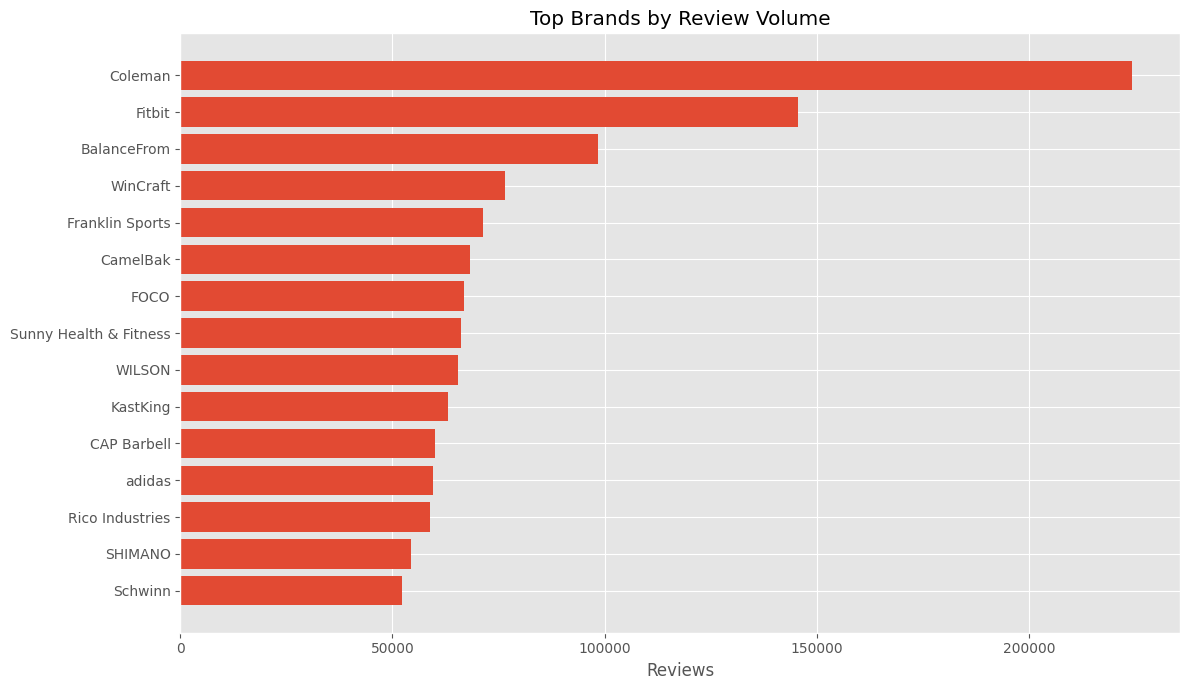

In [51]:
plt.figure(figsize=(12,7))

plt.barh(
    brand_reviews_pd["store"],
    brand_reviews_pd["reviews"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Brands by Review Volume"
)

plt.xlabel("Reviews")

plt.tight_layout()

plt.show()

## Brand Performance Score Ranking

A ranking based solely on average rating may be misleading because brands with very few reviews can achieve extremely high ratings.

To address this, a Brand Performance Score is calculated using both customer satisfaction and review volume.

Score = Average Rating × log10(Review Count)

This approach rewards brands that maintain high ratings while also receiving substantial customer engagement.

In [56]:
from pyspark.sql.functions import (
    count,
    avg,
    log10,
    col,
    desc
)

brand_score = (
    final_v5
    .filter(
        col("store").isNotNull()
    )
    .groupBy("store")
    .agg(
        count("*").alias("reviews"),
        avg("rating").alias("avg_rating")
    )
    .filter(
        col("reviews") > 1000
    )
)

brand_score = (
    brand_score
    .withColumn(
        "brand_score",
        col("avg_rating") *
        log10(col("reviews"))
    )
    .orderBy(
        desc("brand_score")
    )
    .limit(15)
)

brand_score_pd = (
    brand_score
    .toPandas()
)

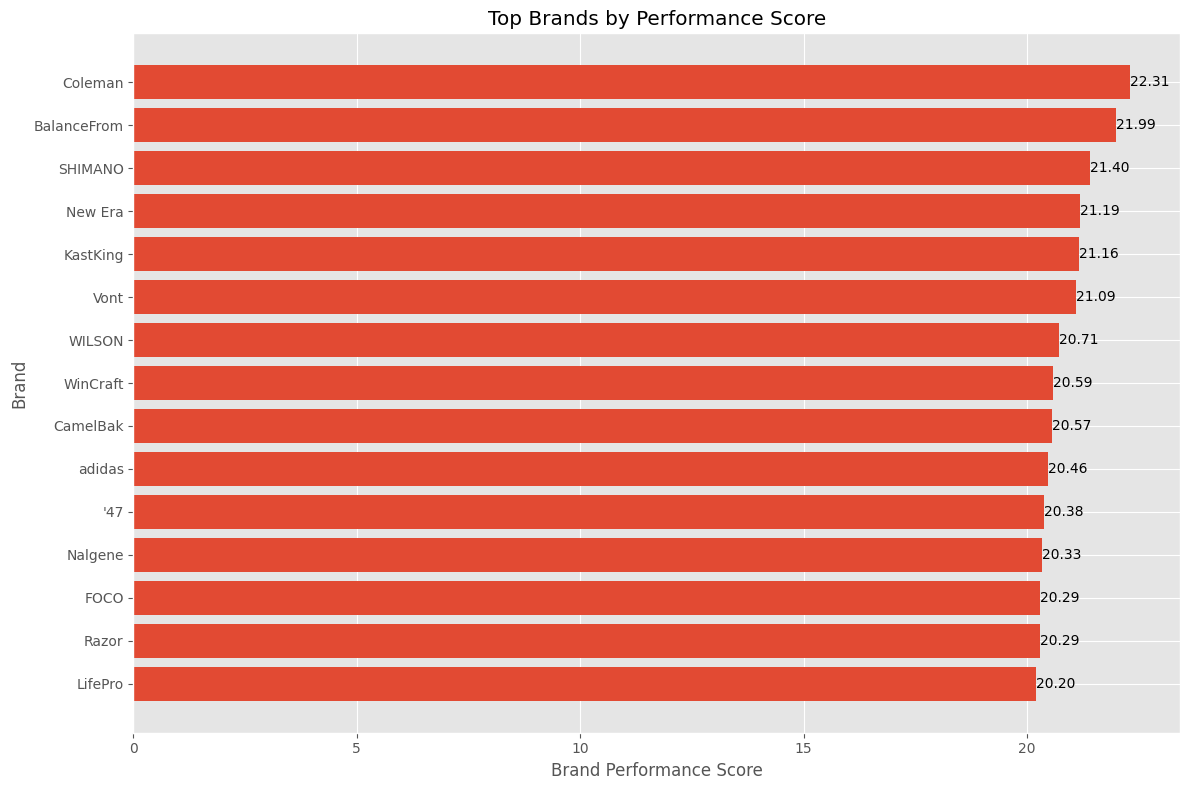

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    brand_score_pd["store"],
    brand_score_pd["brand_score"]
)

plt.xlabel(
    "Brand Performance Score"
)

plt.ylabel(
    "Brand"
)

plt.title(
    "Top Brands by Performance Score"
)

plt.gca().invert_yaxis()

for i, value in enumerate(
    brand_score_pd["brand_score"]
):
    
    plt.text(
        value,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()

plt.show()

## Brand Performance Matrix

This visualization compares customer engagement and customer satisfaction simultaneously.

Brands appearing in the upper-right region demonstrate both high review volumes and strong customer ratings.

These brands represent the strongest overall performers in the marketplace.

In [58]:
brand_matrix = (
    final_v5
    .filter(
        col("store").isNotNull()
    )
    .groupBy("store")
    .agg(
        count("*").alias("reviews"),
        avg("rating").alias("avg_rating")
    )
    .filter(
        col("reviews") > 1000
    )
)

brand_matrix_pd = (
    brand_matrix
    .toPandas()
)

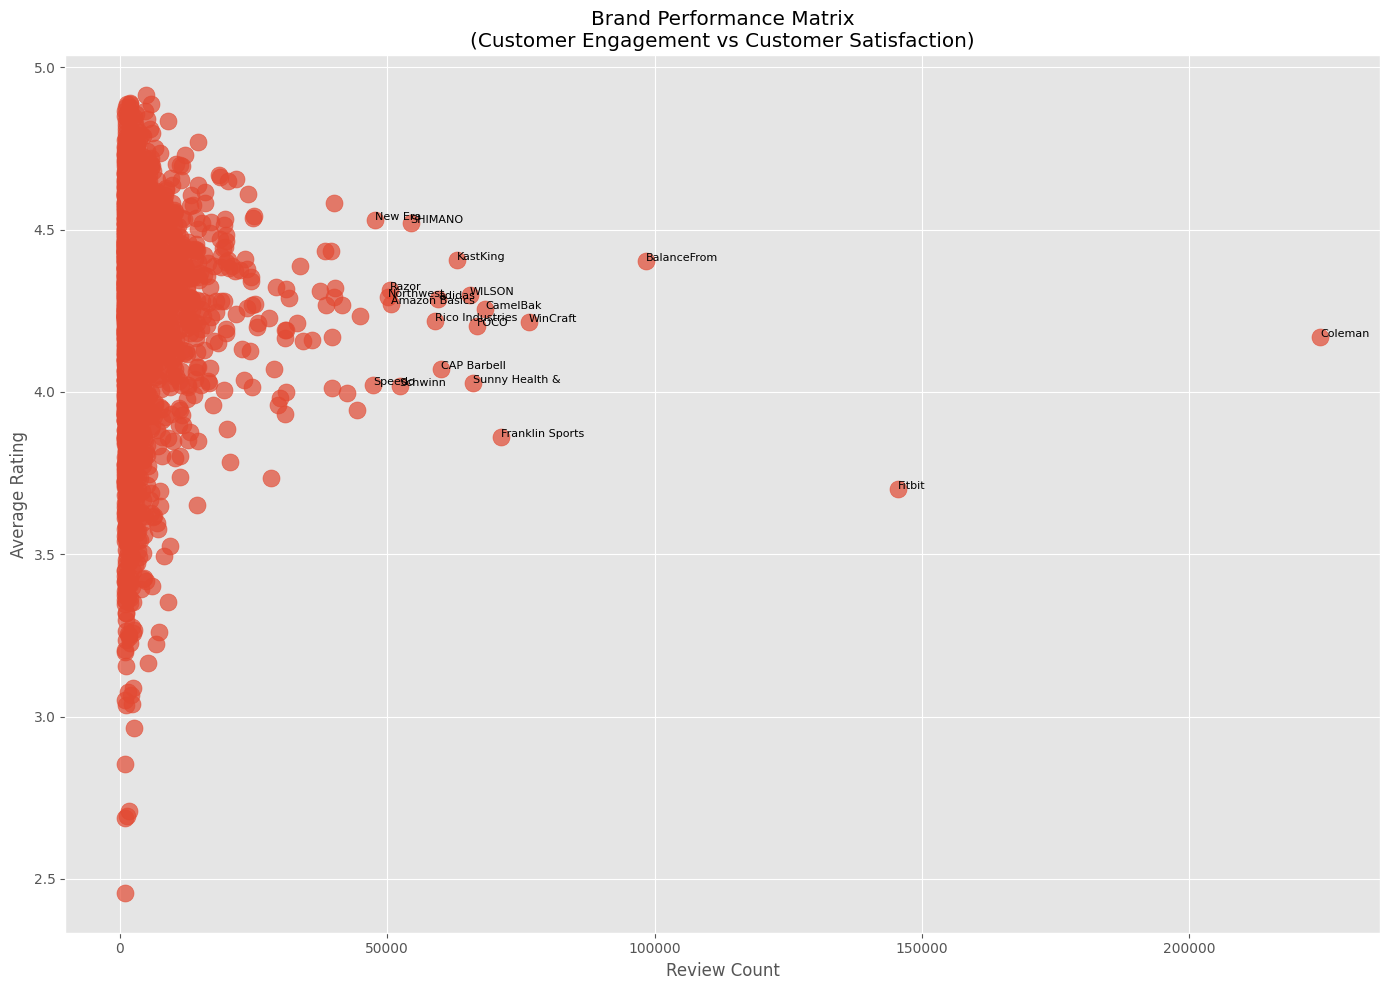

In [59]:
plt.figure(figsize=(14,10))

plt.scatter(
    brand_matrix_pd["reviews"],
    brand_matrix_pd["avg_rating"],
    s=150,
    alpha=0.7
)

for _, row in (
    brand_matrix_pd
    .sort_values(
        "reviews",
        ascending=False
    )
    .head(20)
    .iterrows()
):
    
    plt.annotate(
        row["store"][:15],
        (
            row["reviews"],
            row["avg_rating"]
        ),
        fontsize=8
    )

plt.xlabel(
    "Review Count"
)

plt.ylabel(
    "Average Rating"
)

plt.title(
    "Brand Performance Matrix\n(Customer Engagement vs Customer Satisfaction)"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [60]:
median_reviews = (
    brand_matrix_pd["reviews"]
    .median()
)

median_rating = (
    brand_matrix_pd["avg_rating"]
    .median()
)

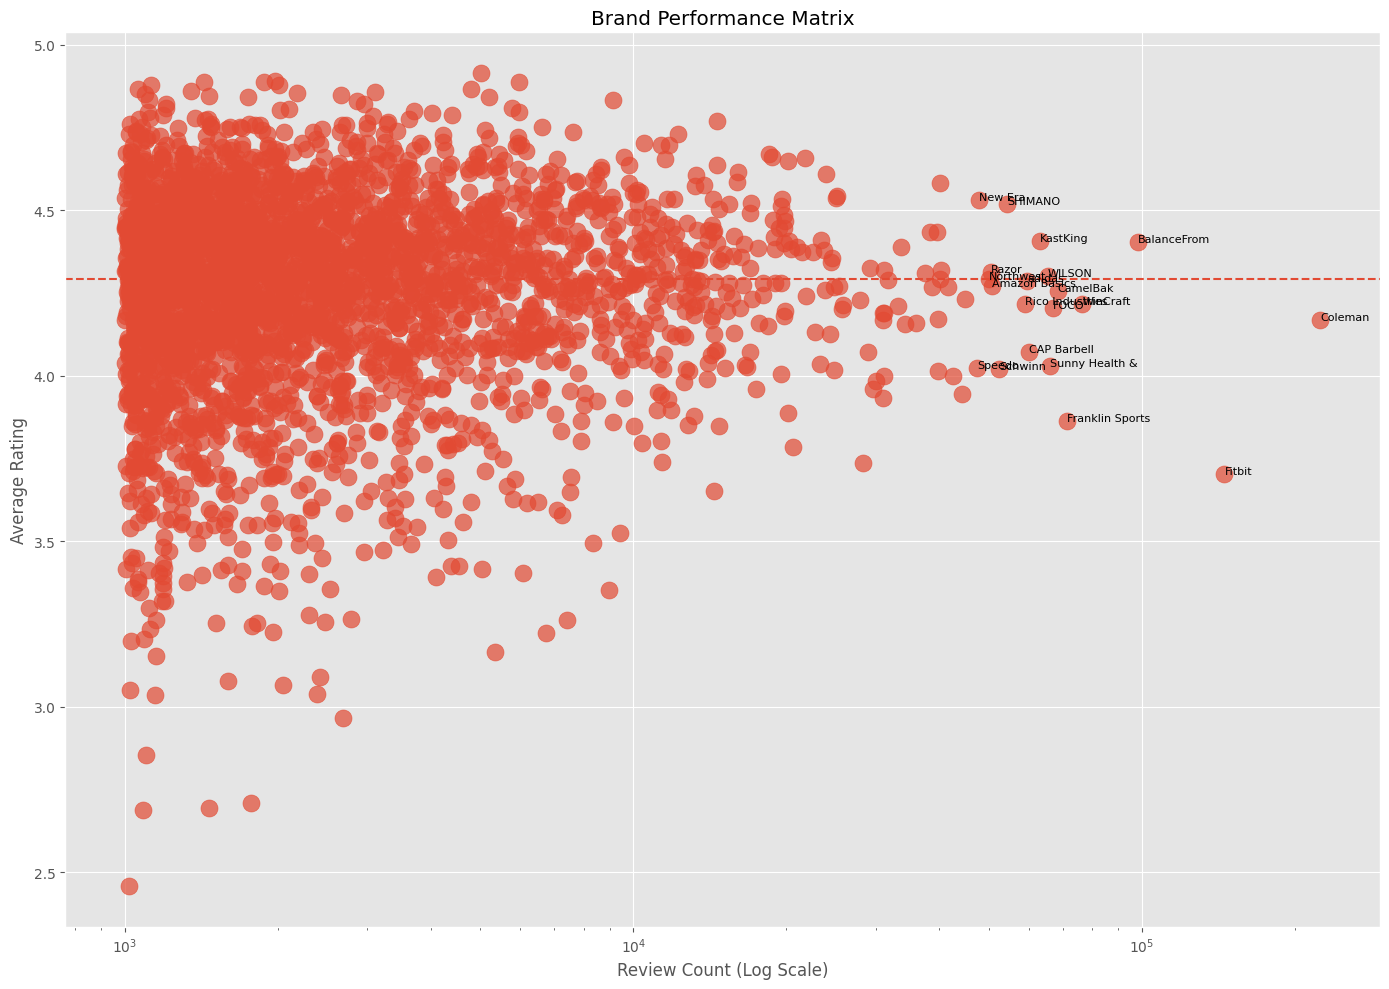

In [62]:
plt.figure(figsize=(14,10))

plt.scatter(
    brand_matrix_pd["reviews"],
    brand_matrix_pd["avg_rating"],
    s=150,
    alpha=0.7
)

plt.xscale("log")

plt.axhline(
    median_rating,
    linestyle="--"
)

for _, row in (
    brand_matrix_pd
    .sort_values("reviews", ascending=False)
    .head(20)
    .iterrows()
):
    plt.annotate(
        row["store"][:15],
        (
            row["reviews"],
            row["avg_rating"]
        ),
        fontsize=8
    )

plt.xlabel("Review Count (Log Scale)")
plt.ylabel("Average Rating")

plt.title(
    "Brand Performance Matrix"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [63]:
from pyspark.sql.functions import count, desc

top_brands = (
    final_v5
    .groupBy("store")
    .count()
    .orderBy(desc("count"))
    .limit(10)
    .select("store")
)

top_brand_list = [
    row["store"]
    for row in top_brands.collect()
]

print(top_brand_list)

['Coleman', None, 'Fitbit', 'BalanceFrom', 'WinCraft', 'Franklin Sports', 'CamelBak', 'FOCO', 'Sunny Health & Fitness', 'WILSON']


In [64]:
brand_growth = (
    final_v5
    .filter(
        col("store").isin(top_brand_list)
    )
    .groupBy(
        "review_year",
        "store"
    )
    .count()
)

brand_growth_pd = (
    brand_growth
    .toPandas()
)

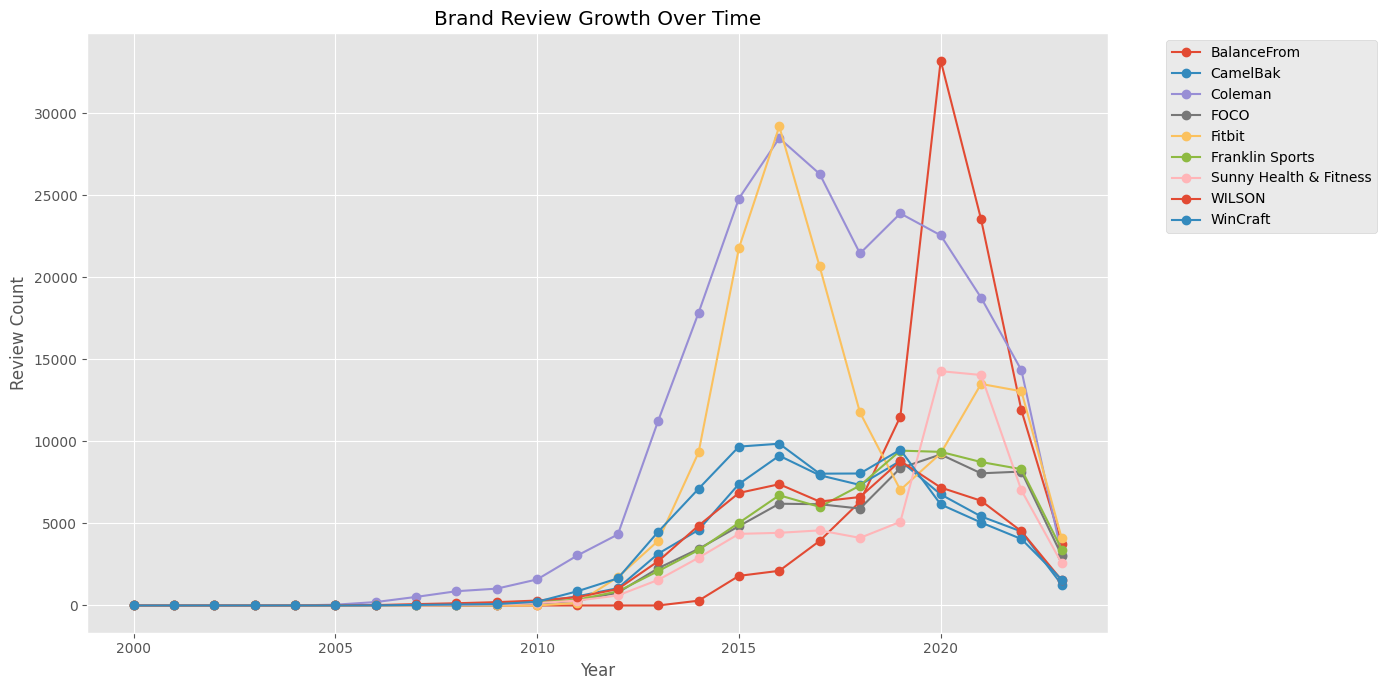

In [65]:
pivot_growth = (
    brand_growth_pd
    .pivot(
        index="review_year",
        columns="store",
        values="count"
    )
    .fillna(0)
)

plt.figure(figsize=(14,7))

for brand in pivot_growth.columns:
    
    plt.plot(
        pivot_growth.index,
        pivot_growth[brand],
        marker="o",
        label=brand
    )

plt.title(
    "Brand Review Growth Over Time"
)

plt.xlabel("Year")
plt.ylabel("Review Count")

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [66]:
brand_rating_year = (
    final_v5
    .filter(
        col("store").isin(top_brand_list)
    )
    .groupBy(
        "review_year",
        "store"
    )
    .agg(
        avg("rating").alias("avg_rating")
    )
)

brand_rating_pd = (
    brand_rating_year
    .toPandas()
)

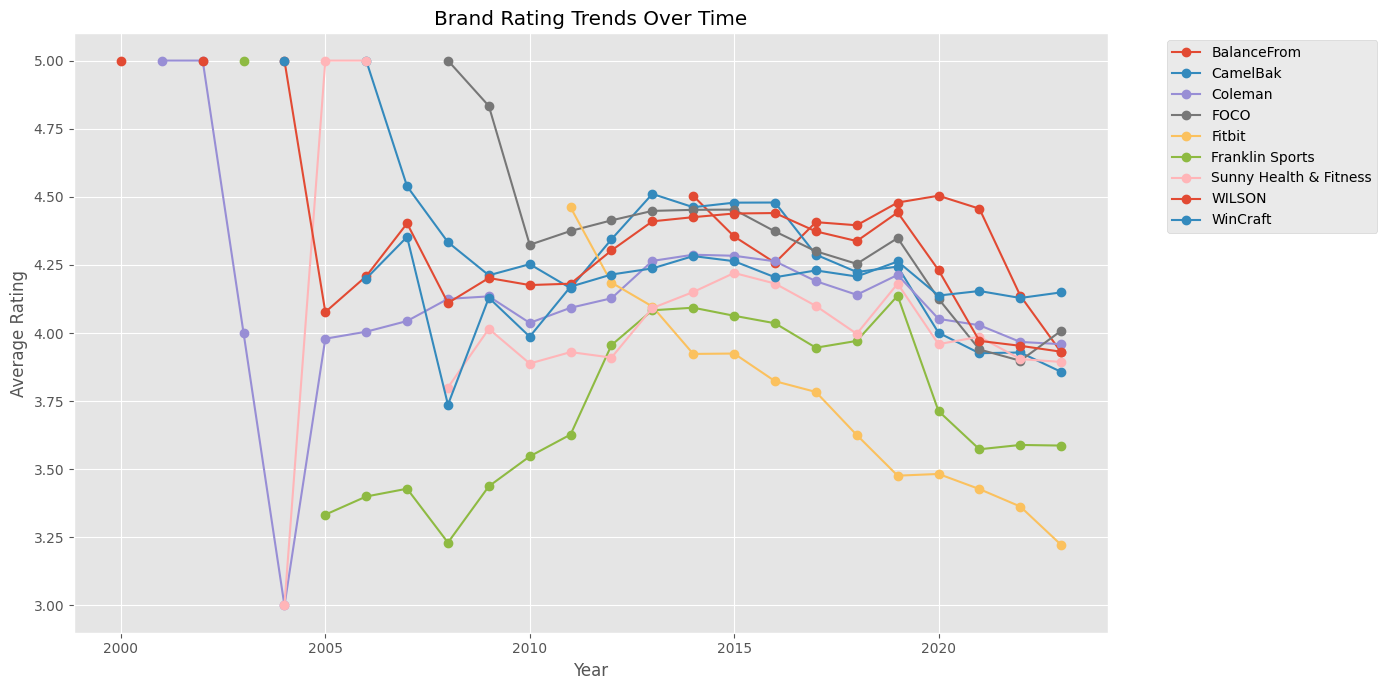

In [67]:
pivot_rating = (
    brand_rating_pd
    .pivot(
        index="review_year",
        columns="store",
        values="avg_rating"
    )
)

plt.figure(figsize=(14,7))

for brand in pivot_rating.columns:
    
    plt.plot(
        pivot_rating.index,
        pivot_rating[brand],
        marker="o",
        label=brand
    )

plt.title(
    "Brand Rating Trends Over Time"
)

plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [68]:
brand_share = (
    final_v5
    .filter(
        col("store").isin(top_brand_list)
    )
    .groupBy(
        "review_year",
        "store"
    )
    .count()
)

brand_share_pd = (
    brand_share
    .toPandas()
)

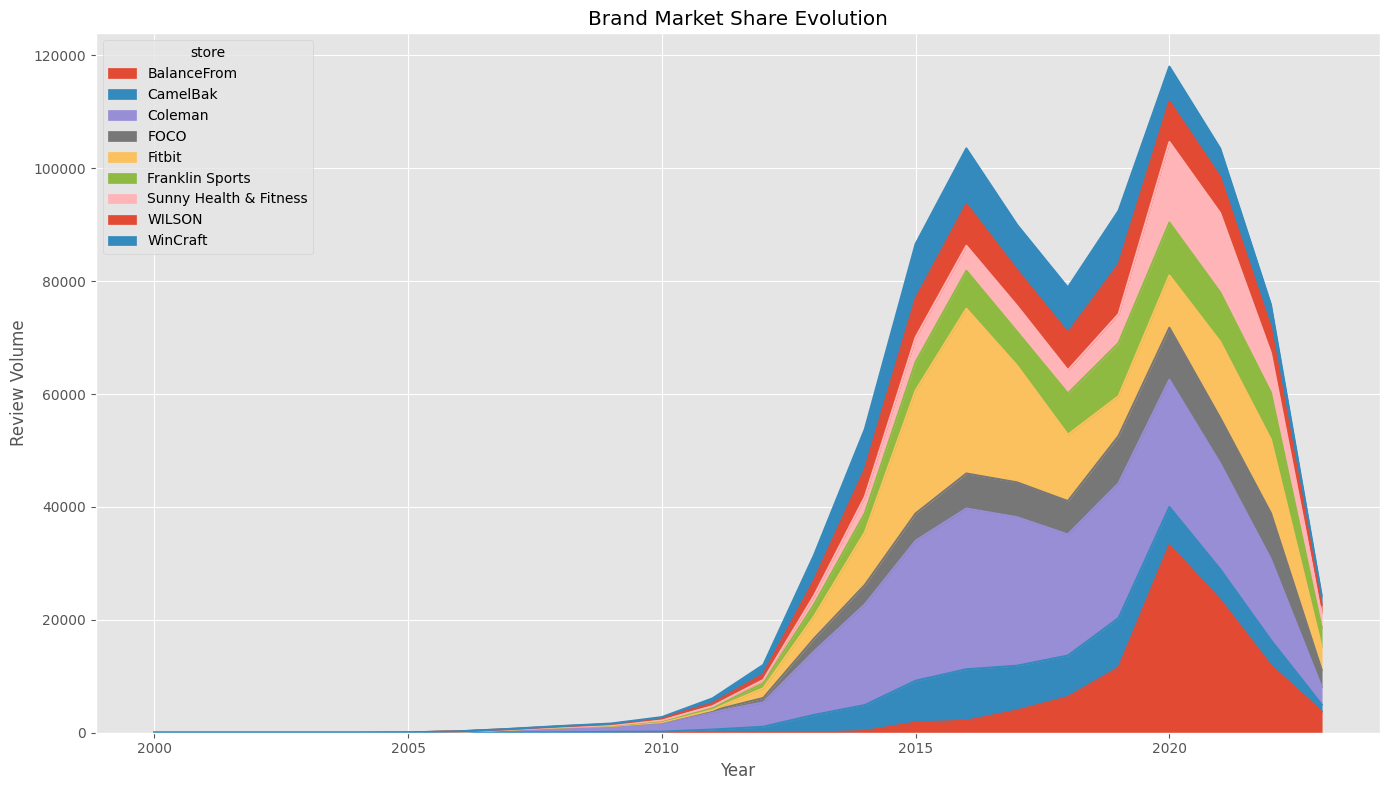

In [69]:
pivot_share = (
    brand_share_pd
    .pivot(
        index="review_year",
        columns="store",
        values="count"
    )
    .fillna(0)
)

pivot_share.plot(
    kind="area",
    figsize=(14,8),
    stacked=True
)

plt.title(
    "Brand Market Share Evolution"
)

plt.xlabel("Year")
plt.ylabel("Review Volume")

plt.tight_layout()

plt.show()

In [70]:
positive_brand = (
    final_v5
    .filter(
        (col("sentiment")=="Positive")
        &
        (col("store").isin(top_brand_list))
    )
    .groupBy(
        "review_year",
        "store"
    )
    .count()
)

positive_pd = (
    positive_brand
    .toPandas()
)

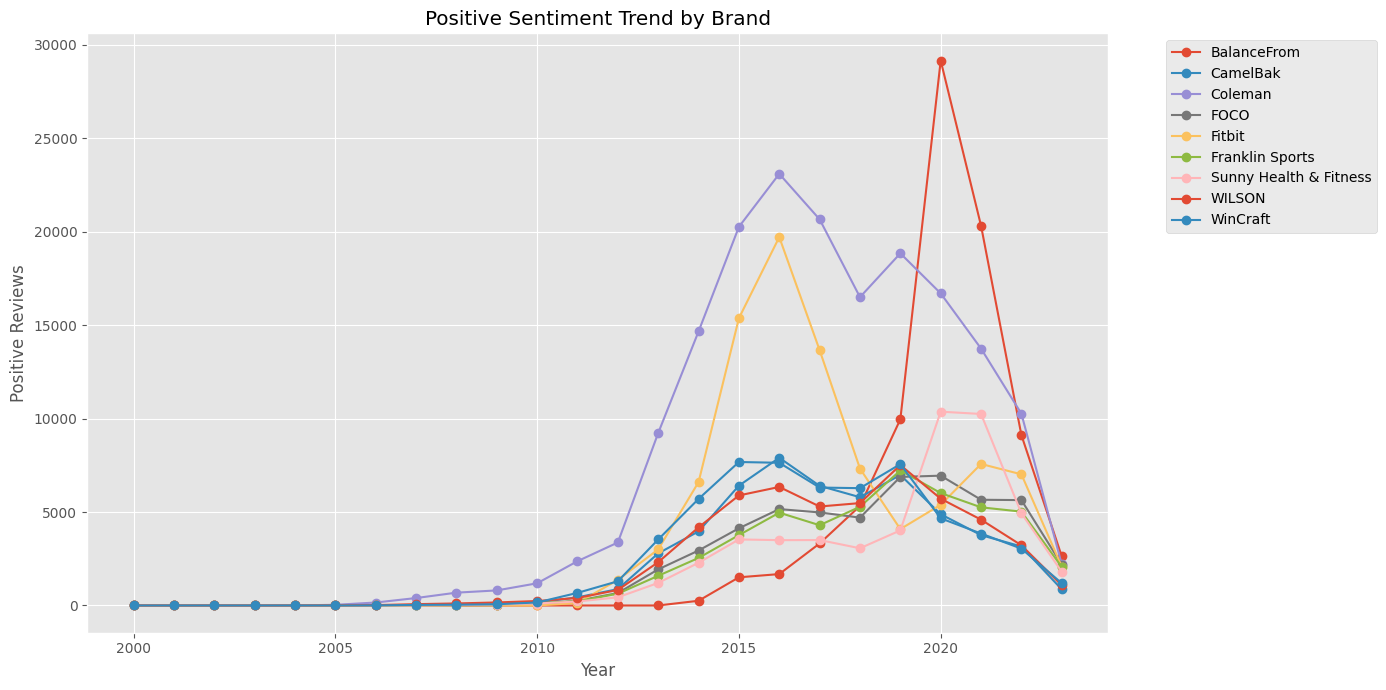

In [71]:
pivot_positive = (
    positive_pd
    .pivot(
        index="review_year",
        columns="store",
        values="count"
    )
    .fillna(0)
)

plt.figure(figsize=(14,7))

for brand in pivot_positive.columns:
    
    plt.plot(
        pivot_positive.index,
        pivot_positive[brand],
        marker="o",
        label=brand
    )

plt.title(
    "Positive Sentiment Trend by Brand"
)

plt.xlabel("Year")
plt.ylabel("Positive Reviews")

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [72]:
recent = (
    final_v5
    .filter(
        col("review_year") >= 2020
    )
)

In [73]:
brand_growth_matrix = (
    recent
    .groupBy("store")
    .agg(
        count("*").alias("reviews"),
        avg("rating").alias("avg_rating")
    )
    .filter(
        col("reviews") > 1000
    )
)

brand_growth_matrix_pd = (
    brand_growth_matrix
    .toPandas()
)

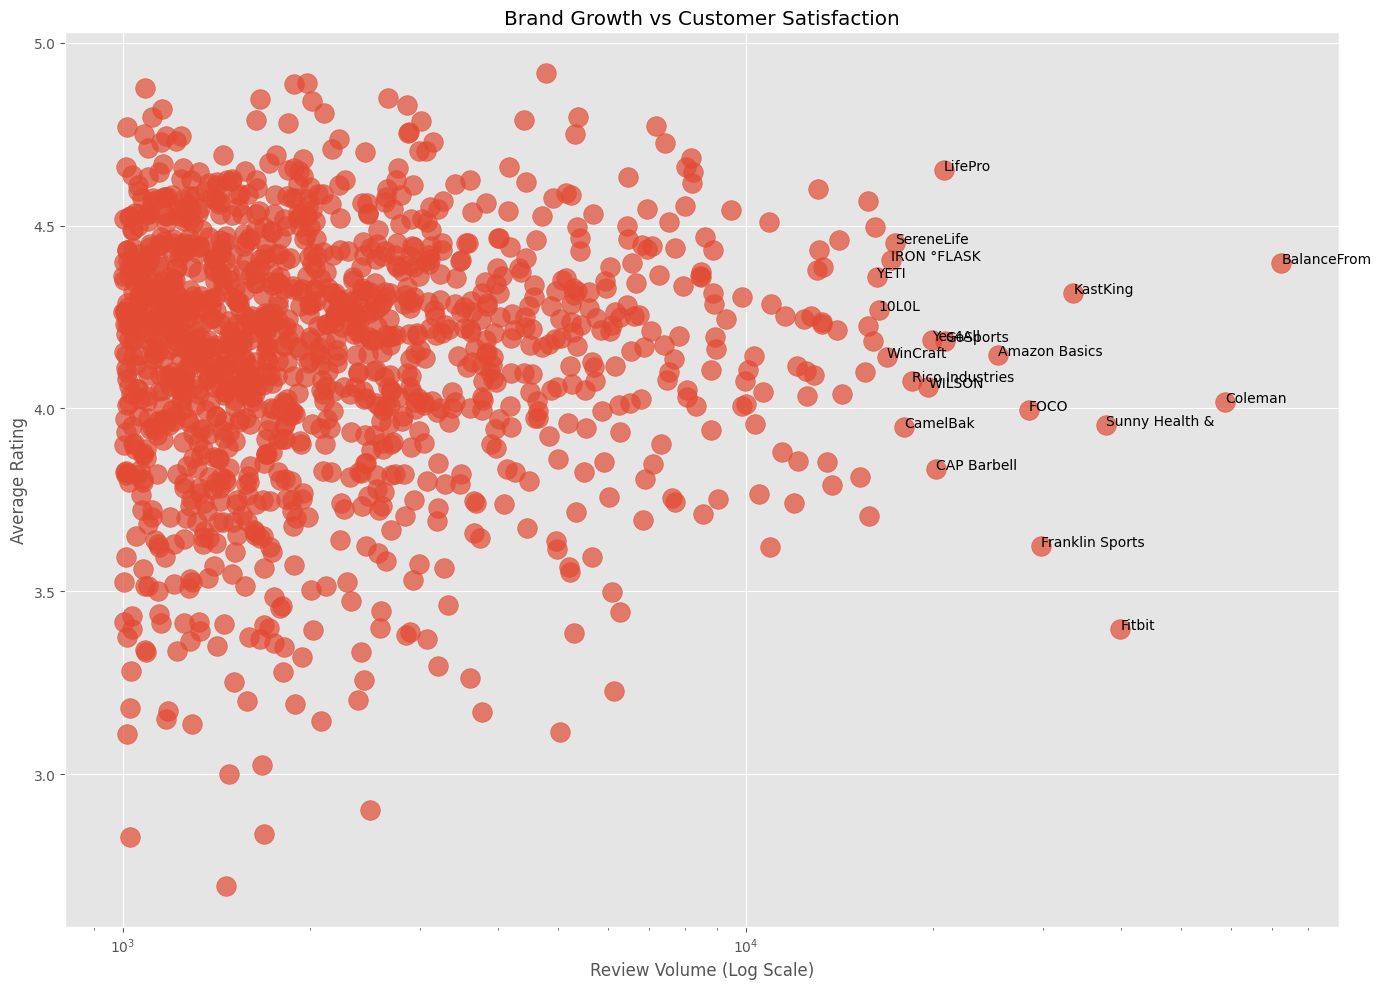

In [74]:
plt.figure(figsize=(14,10))

plt.scatter(
    brand_growth_matrix_pd["reviews"],
    brand_growth_matrix_pd["avg_rating"],
    s=200,
    alpha=0.7
)

plt.xscale("log")

for _, row in (
    brand_growth_matrix_pd
    .sort_values(
        "reviews",
        ascending=False
    )
    .head(20)
    .iterrows()
):
    
    plt.annotate(
        row["store"][:15],
        (
            row["reviews"],
            row["avg_rating"]
        )
    )

plt.xlabel(
    "Review Volume (Log Scale)"
)

plt.ylabel(
    "Average Rating"
)

plt.title(
    "Brand Growth vs Customer Satisfaction"
)

plt.grid(True)

plt.tight_layout()

plt.show()